In [1]:
import numpy as np 
import pandas as pd 
import statistics as sts 
from matplotlib import pyplot as plt 
import seaborn as sns 
import streamlit as st 
import joblib 
import warnings
from sklearn.preprocessing import StandardScaler,MinMaxScaler,LabelEncoder,OrdinalEncoder,PowerTransformer,PolynomialFeatures
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.impute import SimpleImputer,KNNImputer
from sklearn.metrics import r2_score,mean_absolute_error,mean_absolute_error,root_mean_squared_error
from sklearn.feature_selection import SelectKBest,f_regression
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv(r"C:\Shravan\PythonPratice\supervised\machineLearning1\pred13\clothes_price_prediction_data.csv",encoding_errors='ignore')

In [3]:
df1=df.copy()

In [4]:
df1.sample(10)

,Brand,Category,Color,Size,Material,Price
293,Adidas,Jeans,White,M,Denim,39
612,Nike,Shoes,Black,XXL,Nylon,165
292,Nike,Shoes,Yellow,L,Cotton,40
474,Nike,Shoes,Yellow,XXL,Denim,121
801,New Balance,Dress,Black,XL,Denim,48
52,Puma,Shoes,Yellow,XL,Cotton,48
596,Nike,Jacket,Black,L,Wool,124
318,Under Armour,Jeans,Yellow,L,Wool,51
166,New Balance,Jacket,Red,XS,Denim,50
602,Adidas,T-shirt,Green,M,Denim,184


In [5]:
print(df1.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Brand     1000 non-null   object
 1   Category  1000 non-null   object
 2   Color     1000 non-null   object
 3   Size      1000 non-null   object
 4   Material  1000 non-null   object
 5   Price     1000 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 47.0+ KB
None


In [6]:
df1.Material.value_counts().to_dict()

{'Polyester': 175,
 'Silk': 173,
 'Wool': 172,
 'Denim': 163,
 'Cotton': 162,
 'Nylon': 155}

In [7]:
Materail_encoded={'Polyester': 0,
 'Silk': 1,
 'Wool': 2,
 'Denim': 3,
 'Cotton': 4,
 'Nylon': 5}

df1['Material_encoded']=df1['Material'].map(Materail_encoded)

In [8]:
df1.Size.value_counts().to_dict()

{'XS': 196, 'XXL': 173, 'XL': 167, 'S': 166, 'M': 157, 'L': 141}

In [9]:
Size_encoded={'XS': 1, 'XXL': 5, 'XL': 4, 'S': 0, 'M': 2, 'L': 3}

df1['Size_encoded']=df1['Size'].map(Size_encoded)

In [10]:
df1.Color.value_counts().to_dict()

{'Yellow': 173,
 'White': 171,
 'Red': 168,
 'Black': 163,
 'Blue': 163,
 'Green': 162}

In [11]:
Color_encoded={'Yellow': 0,
 'White': 1,
 'Red': 2,
 'Black': 3,
 'Blue': 4,
 'Green': 5}

df1['Color_encoded']=df1['Color'].map(Color_encoded)

In [12]:
df1.Category.value_counts().to_dict()

{'Jacket': 191,
 'Shoes': 172,
 'Jeans': 167,
 'Dress': 166,
 'Sweater': 160,
 'T-shirt': 144}

In [13]:
Category_encoded={'Jacket': 0,
 'Shoes': 1,
 'Jeans': 2,
 'Dress': 3,
 'Sweater': 4,
 'T-shirt': 5}

df1['Category_encoded']=df1['Category'].map(Category_encoded)

In [14]:
df1.Brand.value_counts().to_dict()

{'Under Armour': 179,
 'Puma': 168,
 'Adidas': 166,
 'Nike': 165,
 'New Balance': 164,
 'Reebok': 158}

In [15]:
Brand_encoded={'Under Armour': 0,
 'Puma': 1,
 'Adidas': 2,
 'Nike': 3,
 'New Balance': 4,
 'Reebok': 5}

df1['Brand_encoded']=df1['Brand'].map(Brand_encoded)

In [16]:
df1.sample(10)

,Brand,Category,Color,Size,Material,Price,Material_encoded,Size_encoded,Color_encoded,Category_encoded,Brand_encoded
230,Nike,Shoes,White,XS,Silk,175,1,1,1,1,3
196,Nike,Dress,Blue,XS,Denim,171,3,1,4,3,3
988,Under Armour,Jacket,Black,L,Wool,97,2,3,3,0,0
50,Under Armour,Jacket,Black,XXL,Cotton,63,4,5,3,0,0
990,Nike,Jacket,Green,M,Silk,12,1,2,5,0,3
838,Under Armour,Jeans,Blue,XXL,Polyester,110,0,5,4,2,0
454,Nike,Jeans,White,S,Silk,127,1,0,1,2,3
437,New Balance,Jeans,White,XS,Nylon,165,5,1,1,2,4
356,Nike,Sweater,White,XXL,Silk,180,1,5,1,4,3
172,Under Armour,Dress,Red,S,Nylon,190,5,0,2,3,0


In [17]:
df2=df1.copy()

In [18]:
cata_col=df1.select_dtypes(include='object',exclude='number').columns
cata_col

Index(['Brand', 'Category', 'Color', 'Size', 'Material'], dtype='object')

In [19]:
df2.drop(columns=['Brand', 'Category', 'Color', 'Size', 'Material'],axis=1,inplace=True)

In [20]:
df2.sample(10)

,Price,Material_encoded,Size_encoded,Color_encoded,Category_encoded,Brand_encoded
663,57,0,3,2,1,0
523,168,5,0,3,0,4
786,60,1,5,3,0,2
554,158,2,3,0,3,4
573,56,2,5,2,4,2
321,159,5,4,4,5,0
451,130,1,4,2,4,1
476,93,0,1,1,3,1
983,58,3,1,5,1,4
920,78,1,4,2,5,1


In [21]:
df2.columns

Index(['Price', 'Material_encoded', 'Size_encoded', 'Color_encoded',
       'Category_encoded', 'Brand_encoded'],
      dtype='object')

In [22]:
df3=pd.DataFrame(data=df2,columns=[ 'Material_encoded', 'Size_encoded', 'Color_encoded',
       'Category_encoded', 'Brand_encoded','Price'])

In [23]:
df3.sample(10)

,Material_encoded,Size_encoded,Color_encoded,Category_encoded,Brand_encoded,Price
736,0,2,0,2,0,38
252,1,3,1,0,3,188
653,4,2,3,5,1,143
55,5,3,3,4,4,142
503,2,0,1,0,4,119
456,3,5,1,3,2,136
719,1,1,4,4,1,47
550,3,0,5,4,5,103
387,3,2,5,4,0,191
577,5,1,5,5,0,114


In [24]:
df3[df3.duplicated()]

,Material_encoded,Size_encoded,Color_encoded,Category_encoded,Brand_encoded,Price


In [25]:
df3.drop_duplicates(df3,inplace=True)

In [26]:
df3.sample(10)

,Material_encoded,Size_encoded,Color_encoded,Category_encoded,Brand_encoded,Price
706,3,4,0,2,4,117
4,5,2,1,4,2,113
432,3,4,4,2,0,30
188,4,1,5,3,3,120
971,5,2,1,3,3,53
359,2,5,5,2,1,30
927,3,1,0,1,3,106
420,1,4,0,2,5,154
759,4,1,3,1,4,132
683,0,1,2,4,4,193


                  Material_encoded  Size_encoded  Color_encoded  \
Material_encoded              1.00         -0.04           0.03   
Size_encoded                 -0.04          1.00           0.04   
Color_encoded                 0.03          0.04           1.00   
Category_encoded             -0.01          0.01          -0.02   
Brand_encoded                 0.01         -0.07          -0.01   
Price                         0.02          0.00          -0.02   

                  Category_encoded  Brand_encoded  Price  
Material_encoded             -0.01           0.01   0.02  
Size_encoded                  0.01          -0.07   0.00  
Color_encoded                -0.02          -0.01  -0.02  
Category_encoded              1.00           0.07   0.02  
Brand_encoded                 0.07           1.00   0.04  
Price                         0.02           0.04   1.00  


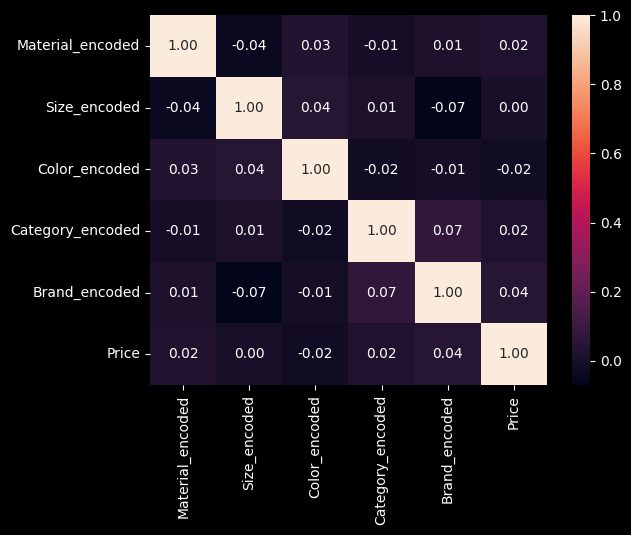

In [27]:
pearson=df3.corr(method='pearson').round(2)
print(pearson)

sns.heatmap(pearson,fmt='.2f',cbar=True,annot=True)
plt.show()

                  Material_encoded  Size_encoded  Color_encoded  \
Material_encoded              1.00         -0.04           0.03   
Size_encoded                 -0.04          1.00           0.04   
Color_encoded                 0.03          0.04           1.00   
Category_encoded             -0.01          0.01          -0.02   
Brand_encoded                 0.02         -0.07          -0.01   
Price                         0.02          0.00          -0.02   

                  Category_encoded  Brand_encoded  Price  
Material_encoded             -0.01           0.02   0.02  
Size_encoded                  0.01          -0.07   0.00  
Color_encoded                -0.02          -0.01  -0.02  
Category_encoded              1.00           0.07   0.02  
Brand_encoded                 0.07           1.00   0.03  
Price                         0.02           0.03   1.00  


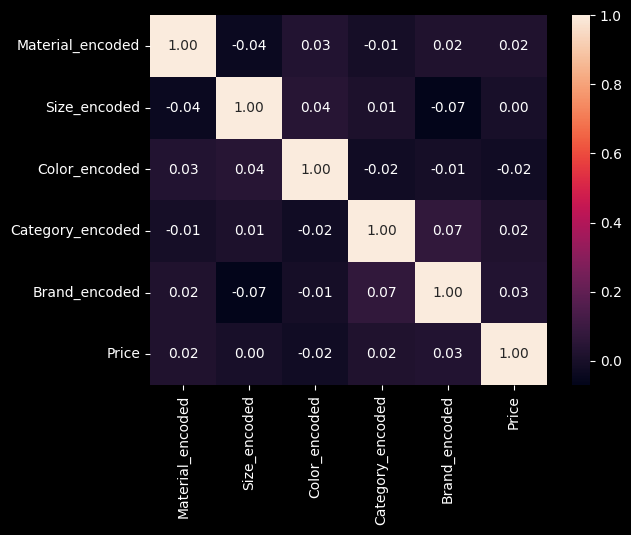

In [28]:
spearman=df3.corr(method='spearman').round(2)
print(spearman)

sns.heatmap(spearman,fmt='.2f',cbar=True,annot=True)
plt.show()

In [29]:
df3.columns

Index(['Material_encoded', 'Size_encoded', 'Color_encoded', 'Category_encoded',
       'Brand_encoded', 'Price'],
      dtype='object')

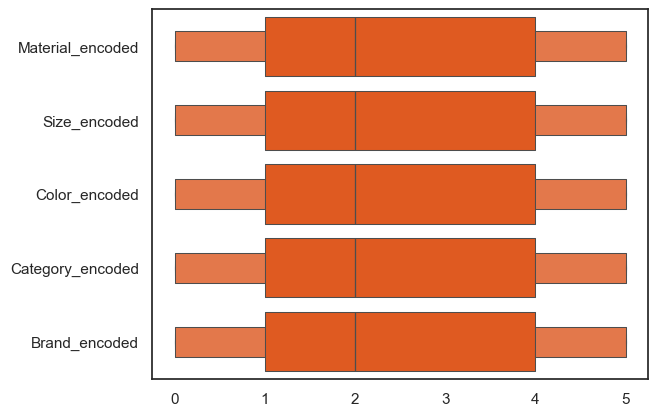

In [30]:

cl1=['#ff4d01']


sns.set_theme(style='white',palette=cl1)
sns.boxenplot(df3[['Material_encoded', 'Size_encoded', 'Color_encoded', 'Category_encoded',
       'Brand_encoded']],palette=cl1,orient='h')

plt.savefig("p6.png",dpi=100)
plt.show()

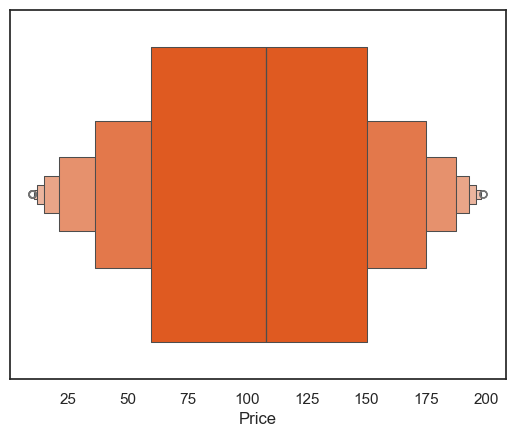

In [31]:
cl1=['#ff4d01']


sns.set_theme(style='white',palette=cl1)
sns.boxenplot(df3['Price'],palette=cl1,orient='h')

plt.savefig("p7.png",dpi=100)
plt.show()

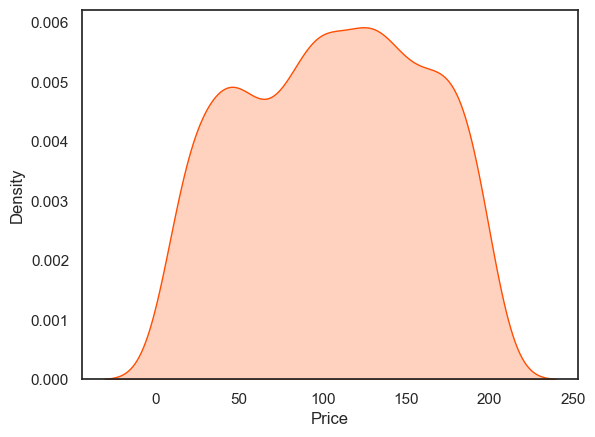

In [32]:
cl1=['#ff4d01']


sns.set_theme(style='white',palette=cl1)
sns.kdeplot(df3['Price'],fill=True,palette=cl1)

plt.savefig("p8.png",dpi=100)
plt.show()

In [33]:
df3.isna().sum()

Material_encoded    0
Size_encoded        0
Color_encoded       0
Category_encoded    0
Brand_encoded       0
Price               0
dtype: int64

In [34]:
df3.isnull().sum()

Material_encoded    0
Size_encoded        0
Color_encoded       0
Category_encoded    0
Brand_encoded       0
Price               0
dtype: int64

In [35]:
class AnomoliesInterClass:
    def __init__(self,data):
        self.data=data
    def anomolies_function(self,col):
        Q1=self.data[col].quantile(0.25)
        Q3=self.data[col].quantile(0.75)
        IQR=Q3-Q1
        lower_bound=Q1-1.5*IQR 
        upper_bound=Q3+1.5*IQR 
        mask=(self.data[col]<lower_bound) | (self.data[col]>upper_bound)
        anomolies_indexes=self.data[col][mask].index.to_list()
        anomolies_data=self.data[col][mask].to_list()
        return anomolies_indexes, list(anomolies_data)
    
num_col=df3.select_dtypes(include='number',exclude='object').columns
AnomoliesInterClass_Instance=AnomoliesInterClass(df3)
anomolies_index_store=set()

for each_col in num_col:
    anomolies_indexes,anomolies_data=AnomoliesInterClass_Instance.anomolies_function(each_col)
    total_anomolies=len(anomolies_data)
    print(f"anomolies length is {total_anomolies}")
    if anomolies_indexes:
        print(f"{each_col} --> {anomolies_indexes}")
        import time 
        time.sleep(2)
        print("anomolies_indexes storing into set")
        anomolies_index_store.update(anomolies_indexes)
    else:
        print(f"{each_col} --> Anomolies not found in this column")
        
df4=df3.drop(list(anomolies_index_store),axis=0)
print(f"old shape is {df3.shape} and new shape is {df4.shape}")       

anomolies length is 0
Material_encoded --> Anomolies not found in this column
anomolies length is 0
Size_encoded --> Anomolies not found in this column
anomolies length is 0
Color_encoded --> Anomolies not found in this column
anomolies length is 0
Category_encoded --> Anomolies not found in this column
anomolies length is 0
Brand_encoded --> Anomolies not found in this column
anomolies length is 0
Price --> Anomolies not found in this column
old shape is (1000, 6) and new shape is (1000, 6)


In [36]:
x=df4.iloc[:,:-1]
y=df4.iloc[:,-1]

In [37]:
best_cols=SelectKBest(score_func=f_regression,k=5)
best_cols.fit_transform(x,y)

new_cols=x.columns[best_cols.get_support()]
new_cols

Index(['Material_encoded', 'Size_encoded', 'Color_encoded', 'Category_encoded',
       'Brand_encoded'],
      dtype='object')

In [38]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [39]:
linear_reg=LinearRegression(n_jobs=-1)
poly=PolynomialFeatures(degree=4,include_bias=True)
decesion_tree=DecisionTreeRegressor(criterion='absolute_error',max_depth=10,min_samples_split=20,min_samples_leaf=20,splitter='random',max_features='sqrt',random_state=12)
random_forest=RandomForestRegressor(criterion='absolute_error',n_estimators=10,n_jobs=-1,min_samples_leaf=10,min_samples_split=20,max_depth=10,max_features='sqrt',random_state=42)

In [47]:
knn=KNeighborsRegressor(n_neighbors=5)

In [50]:
knn.fit(x_train,y_train)

y_pred3=knn.predict(x_test)
print(y_pred3)

joblib.dump(knn,"knn.joblib")

[ 85.8 177.6 101.4  76.  136.4 102.6  98.6  77.  104.2 123.4 121.6 137.8
  64.   91.6  87.  111.8  78.8 100.2 103.4 107.6 101.   65.8 115.8  96.2
 138.2  73.2  86.2 110.8 106.6  73.  110.4 130.8 136.  102.2 145.8 106.
 107.4 121.2  70.  127.6 119.4 105.4  98.4 106.6 102.   77.4  78.6 127.6
 107.4  87.   93.2  88.4  83.2 102.2 114.2 119.8  81.  119.2  92.2 107.
  77.6 132.4  95.4 102.2 114.6 139.2  89.  138.2 118.8 107.4 102.8 132.
  96.4 131.6  68.6 121.   69.6  91.2 123.6 129.8  84.  135.4 126.   77.4
 106.  113.4 156.4 166.   94.6  63.6 147.8 105.8  82.2 129.6 105.8 122.6
  89.8  88.2 140.8 101.  105.4  79.6 122.2 121.6 172.4 158.   81.4  95.2
 116.   98.6  98.2 128.4  78.6 144.8 137.8  91.6  78.8 142.6  97.4 132.
 131.8 118.   96.   72.8  51.  141.4 127.4 100.4 108.4 106.8 115.   98.2
  93.2 125.4 122.4 117.6  89.8 141.4 151.8 138.2  93.6 136.4  82.8  93.
  98.8 131.4 104.  140.8 133.6  90.8  73.8 127.6 108.8  87.  129.8 128.2
 131.2 141.2 108.  136.6  87.  139.4  99.6  99.8 118.6  

['knn.joblib']

In [40]:
cross_score1=cross_val_score(linear_reg,x,y,scoring='r2',cv=20)
cross_score2=cross_val_score(poly,x,y,scoring='r2',cv=20)
cross_score3=cross_val_score(decesion_tree,x,y,scoring='r2',cv=20)
cross_score4=cross_val_score(random_forest,x,y,scoring='r2',cv=20)

mean_value=np.mean(cross_score1)
print(abs(mean_value))

mean_value1=np.mean(cross_score3)
print(abs(mean_value1))

mean_value2=np.mean(cross_score4)
print(abs(mean_value2))

0.03470711375066733
0.10599774409264451
0.06801181514903143


In [41]:
linear_reg.fit(x_train,y_train)

y_pred1=linear_reg.predict(x_test)
print(y_pred1)

joblib.dump(linear_reg,"linear_reg.joblib")

[100.604818   112.14320909 110.95720004 105.77873376 106.09539285
 107.19147222 102.00103984 106.26582741 107.32070888 108.72686193
 105.52370488 111.44747585 102.55165462 107.08141783 106.99383064
 106.03644789 107.53219736 106.97323468 104.50482991 105.75246917
 112.23914418 106.54444511 112.14086659 104.91426759 109.79399146
 107.52700597 105.42746217 111.47309956 108.54068954 101.73751909
 114.18567319  99.77225939 105.14853089 104.57918541 107.90909266
 107.89368809 113.1304841  106.32731365 108.41678824  99.04772027
 109.08471892 112.16163217 104.85780312 107.44430256 103.99869796
 108.40470383 106.07462727 109.14651875 103.37274405 100.98185726
 103.07824454 102.17288808 100.41206021 104.89397924 105.93878553
 113.99495028 102.97307394 108.70609635 109.29620741 106.11945891
  99.23877645 101.21612056 106.72481088 111.5683646  110.3718288
 111.40312145 101.96628338 112.31349968 112.43709337 105.02982098
 104.96599224 111.9812664  108.24635368 109.69934761 112.56633003
 105.360470

['linear_reg.joblib']

In [42]:
decesion_tree.fit(x_train,y_train)

y_pred1=decesion_tree.predict(x_test).astype(int)
print(y_pred1)

joblib.dump(decesion_tree,"decesiontree.joblib")

[117 125 120  99 125 111 125 140  88 120 110 101  88  99  99 111 128 109
 101 115 101 101 114 114 105 128  88 114 100  99 100 109 117 140  99 109
 146 128 100  99 105 114 101 128 111 101 125 146  99  99  88 101 101  86
 109 125 101 120 120  99 125  88 114 106 120  86 115 125 100 117 128 136
 111 136  88 105 101  95 136 100 140  99 125  99  95  99 106 120 111  86
 146  99  95  99 109 100 100 101 117 100 100 146  88 101 146 101 136  99
 117 140  88 120 120 140 125  88  88 136  99  99 114 140 111  99  95 128
  86  99 101  88  86 125 105 125 128 125 106 146 140 136 120 117 100  99
  99 117 111 101 110  86 125 109  99 101 120  99 100 125 140 115 128 105
 101 128 136 111 128  99 100 125 101  88 111  86  86 109 125 128 101 120
 128  99  99 101  86 136 128 111 125 125 101 136 111 125 101  88 111 101
 125  88]


['decesiontree.joblib']

In [43]:
df4.columns.to_list()

['Material_encoded',
 'Size_encoded',
 'Color_encoded',
 'Category_encoded',
 'Brand_encoded',
 'Price']

In [44]:
df4.describe()

,Material_encoded,Size_encoded,Color_encoded,Category_encoded,Brand_encoded,Price
count,1000.000000,1000.00000,1000.00000,1000.000000,1000.000000,1000.000000
mean,2.429000,2.46600,2.45800,2.364000,2.441000,106.289000
std,1.702309,1.73547,1.71148,1.705407,1.713317,53.695444
min,0.000000,0.00000,0.00000,0.000000,0.000000,10.000000
25%,1.000000,1.00000,1.00000,1.000000,1.000000,59.750000
50%,2.000000,2.00000,2.00000,2.000000,2.000000,108.000000
75%,4.000000,4.00000,4.00000,4.000000,4.000000,150.000000
max,5.000000,5.00000,5.00000,5.000000,5.000000,199.000000


In [45]:
random_forest.fit(x_train,y_train)

y_pred1=random_forest.predict(x_test).astype(int)
print(y_pred1)
joblib.dump(random_forest,"random_forest.joblib")

[ 95 133 127 108 107 108 104 102 108  83 103 103  80 113 104 103 105 143
 105 106  94 114 126  97 122 105  99 121 107 108 118 104 119 111 106 104
 135 109  92  96 120 110 108 122  89 113 109 123 107  87 102 102 102 118
 115 101 103 104 105  99 122  95  99 118 119  89  95 113 109 100  96 114
 110 125 101 115 112 118  89 112  82 110 125  94  95 112 114 120 116  93
 125  87 112 111 114  92 106 102 107 121 113 109  89  95 123 106 100 104
 110 120 110 115  93 119 118 111  94 105  84 110 114 123 101 111  83  92
  99 112 101  93 100  91 109 105 125 101 123 132 126 117  85 108 104 105
 107 111 113 113 123  92  92 121 109 118 119 122 104 109  97 109 127 122
 105 131 102 104 110 109 108 116 111  95 116 103 111 106  98  99  98 135
 107 127  97 104 107 111 112 112 115 120  93 112 111 114 113 116 105 112
 105 109]


['random_forest.joblib']

--------------------------------
name of the model is linear_reg
--------------------------------


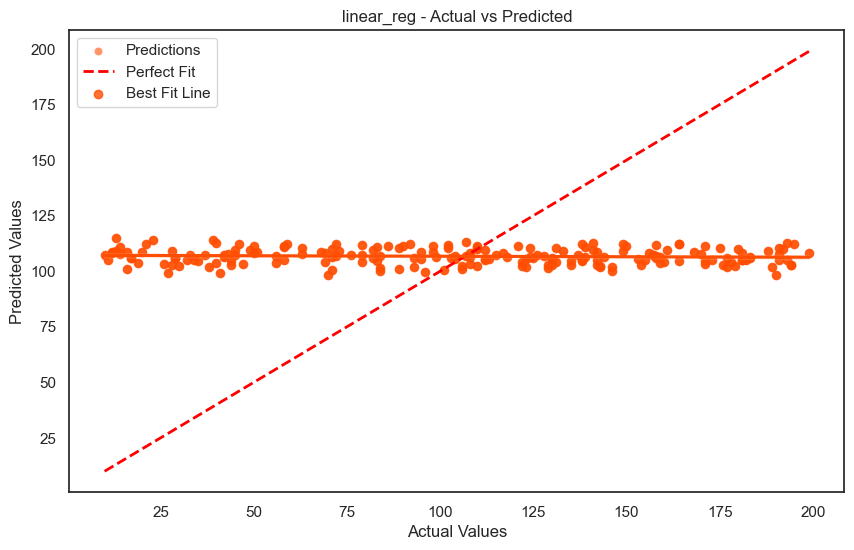

--------------------------------
name of the model is polynomial_reg
--------------------------------


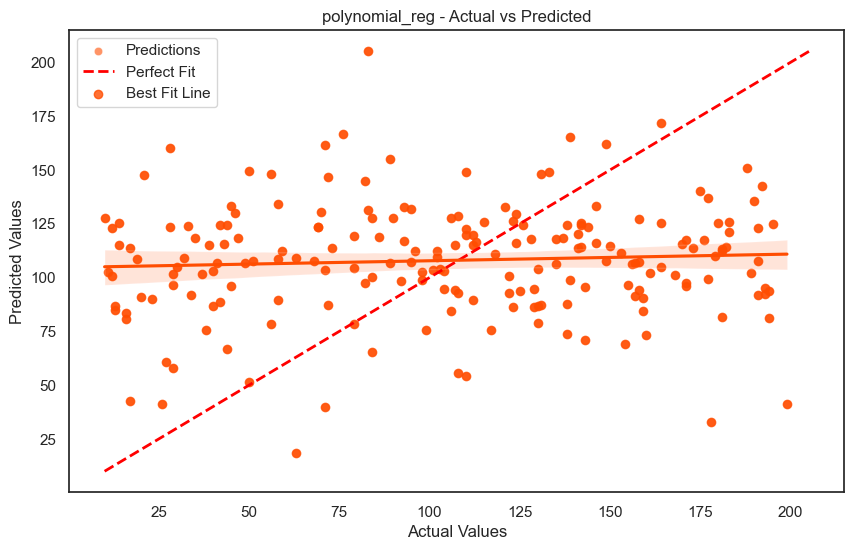

--------------------------------
name of the model is decesion_tree
--------------------------------


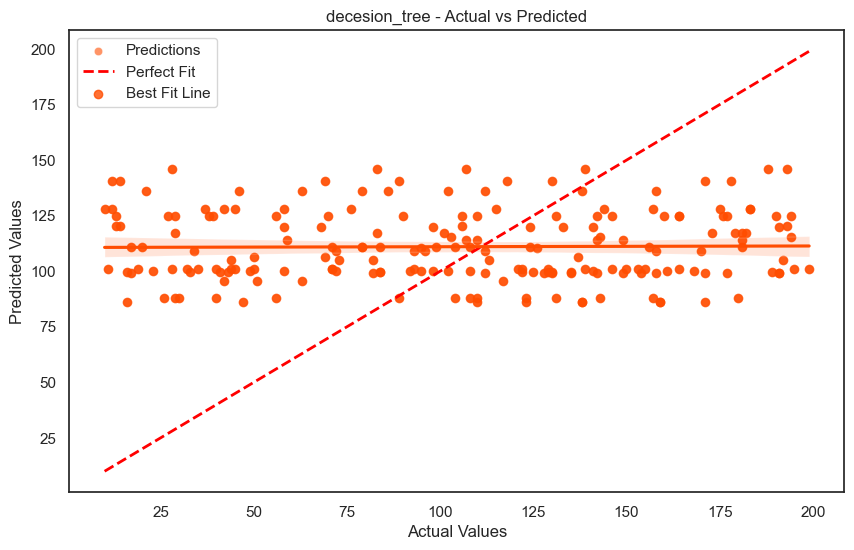

--------------------------------
name of the model is random_foreset
--------------------------------


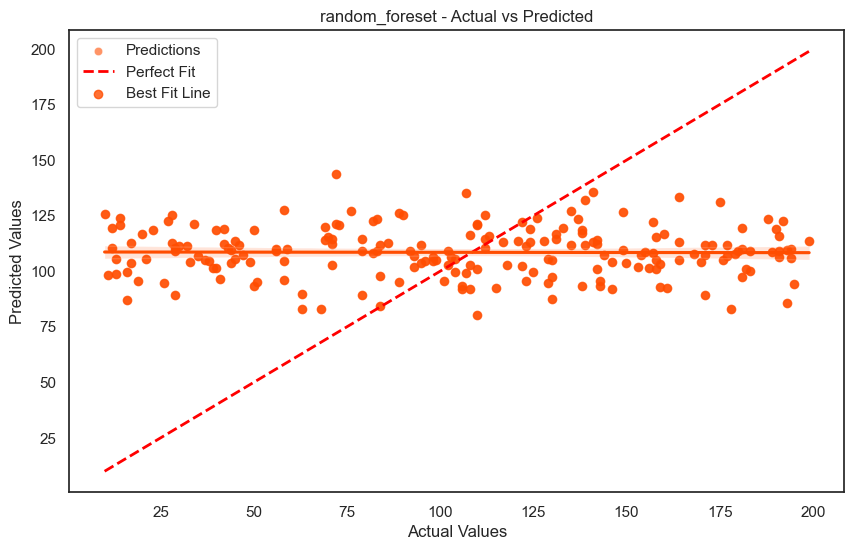

In [46]:

pipeline1=Pipeline(steps=[
    ("LinearRegression",linear_reg)
])
pipeline2=Pipeline(steps=[
    ("polynomolial",poly),
    ('LinearRegression',linear_reg)
])
pipeline3=Pipeline(steps=[
    ("Decesion_tree",decesion_tree)
])

pipeline4=Pipeline(steps=[
    ("random_foreset",random_forest)
])


model_dict={
    "linear_reg":pipeline1,
    "polynomial_reg":pipeline2,
    "decesion_tree":pipeline3,
    "random_foreset":pipeline4
}

for name, model in model_dict.items():
    print("--------------------------------")
    print(f"name of the model is {name}")
    model.fit(x_train, y_train)
    print("--------------------------------")
    y_pred = model.predict(x_test)
    # print(y_pred)
    
    # Create scatter plot of actual vs predicted
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, label='Predictions')
    
    # Draw the perfect prediction line (best fit would be y=x)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Fit')
    
    # Add regression line through predictions
    sns.regplot(x=y_test, y=y_pred,  label='Best Fit Line')
    
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(f'{name} - Actual vs Predicted')
    plt.legend()
    plt.show()